In [22]:
import os

import matplotlib.pyplot as plt
plt.style.use('bmh')
import pandas as pd

def load_training_data(folder_path):
    """Load training data from a CSV log file."""
    files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    dfs = []
    filename_to_label = {
        'DQN_34.csv': '40dBm',
        'DQN_38.csv': '30dBm',
        'DQN_36.csv': '20dBm',
        'DQN_37.csv': '10dBm',
    }
    for file in files:
        df = pd.read_csv(os.path.join(folder_path, file))
        df.columns = ['Wall time', 'Step', f'Secrecy_Rate_{filename_to_label.get(file, file)}']
        dfs.append(df)

    # Merge all dataframes on 'Step' and not 'Wall time' to align steps across different runs
    merged_df = dfs[0]
    for df in dfs[1:]:
        df = df.drop(columns=['Wall time'])  # Drop 'Wall time' to avoid merge conflicts
        merged_df = pd.merge(merged_df, df, on='Step')
    merged_df.sort_values('Step', inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    return merged_df


folder_path = 'results_plots/fpa_80'
data = load_training_data(folder_path)
data.head()

,Wall time,Step,Secrecy_Rate_30dBm,Secrecy_Rate_20dBm,Secrecy_Rate_10dBm,Secrecy_Rate_40dBm
0,1.773681e+09,400,16.710503,13.672899,11.138834,18.013237
1,1.773681e+09,800,16.378452,14.588288,12.189884,17.950100
2,1.773681e+09,1200,18.459867,13.443685,10.404335,18.148693
3,1.773681e+09,1600,18.279919,12.725440,10.124956,18.448978
4,1.773681e+09,2000,17.923754,13.711062,10.327621,18.379381


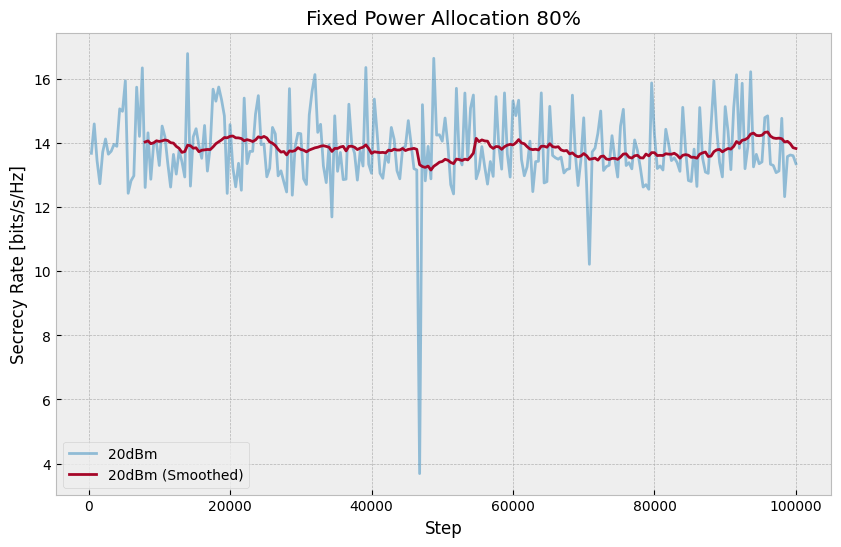

In [23]:
def plot_training_curves(data, title, powers_to_plot, add_smoothing=False, save=False):
    plt.figure(figsize=(10, 6))
    for column in data.columns:
        if column.startswith('Secrecy_Rate_') and any(power in column for power in powers_to_plot):
            if add_smoothing:
                plt.plot(data['Step'], data[column], label=column.replace('Secrecy_Rate_', ''), alpha=0.5)
                plt.plot(data['Step'], data[column].rolling(window=20).mean(), label=f'{column.replace("Secrecy_Rate_", "")} (Smoothed)', linewidth=2)
            else:
                plt.plot(data['Step'], data[column], label=column.replace('Secrecy_Rate_', ''))
    plt.xlabel('Step')
    plt.ylabel('Secrecy Rate [bits/s/Hz]')
    plt.title(title)
    plt.legend()
    if save:
        plt.savefig(f'results_plots/plot_images/{title.replace(" ", "_").lower()}.png')
    plt.show()

# powers_to_plot = ["40dBm", "30dBm", "20dBm", "10dBm"]
powers_to_plot = ["20dBm"]
plot_training_curves(data, 'Fixed Power Allocation 80%', powers_to_plot, add_smoothing=True, save=True)